# Per-Pulse Per-Run Outlier Analysis
Same as `2_per_pulse_outlier.ipynb` but uses the **non-merged** data (`ro_*.h5`)  
so each `run_start` within a pulse shape produces its own outlier probability.  
The final scatter plot shows **all** per-run outlier values for each pulse shape.

In [1]:
import os
import glob
import re

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.protocols.single_state_outlier import SingleStateOutlierAnalyzer

## 1. Configuration

In [10]:
# Path to the per_pulse folder produced by 1_pulse_shape_stable_merge.ipynb
PULSE_DIR = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse"

# Outlier detection threshold (number of sigma)
OUTLIER_SIGMA = 3

# Mapping from pulse name to an integer index for the x-axis
PULSE_ORDER = {
    "readout_square": 4000,
    "readout_three_step": 100,
    "readout_three_step_120": 120,
    "readout_three_step_140": 140,
    "readout_three_step_160": 160,
    "readout_three_step_200": 200,
    "readout_three_step_240": 240,
    "readout_three_step_300": 300,
    "readout_three_step_340": 340,
    "readout_three_step_400": 400,
    "readout_three_step_500": 500,
    "readout_three_step_600": 600,
    "readout_three_step_800": 800,
    "readout_three_step_1000": 1000,
    "readout_three_step_1200": 1200,
}

# Output
FIGURE_SAVE_PATH = os.path.join(os.path.dirname(PULSE_DIR), "figures", "per_pulse_per_run_outlier")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

## 2. Discover Non-Merged Files
Look for `ro_*.h5` files that are **not** `*_merged.h5`.

In [11]:
pattern = os.path.join(PULSE_DIR, "ro_*.h5")
all_h5 = sorted(glob.glob(pattern))

# Exclude merged files
pulse_files = {}
for f in all_h5:
    basename = os.path.basename(f)
    if basename.endswith("_merged.h5"):
        continue
    m = re.match(r"ro_(.+)\.h5$", basename)
    if m:
        pulse_files[m.group(1)] = f

print(f"Found {len(pulse_files)} non-merged pulse files:")
for name, path in pulse_files.items():
    print(f"  {name:40s}  {path}")

Found 5 non-merged pulse files:
  readout_square                            D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_square.h5
  readout_three_step                        D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step.h5
  readout_three_step_1000                   D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_1000.h5
  readout_three_step_200                    D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_200.h5
  readout_three_step_400                    D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_400.h5


## 3. Reference Fit (I1_1/Q1_1) — Per Run
For each pulse shape, iterate over `run_start` and run `SingleStateOutlierAnalyzer` per run.

In [12]:
analyzer = SingleStateOutlierAnalyzer()

ref_results = {}  # pulse_name -> list of (results_dict, run_ds, run_start_val)

for pulse_name, h5_path in pulse_files.items():
    print(f"\n{'='*60}")
    print(f"Pulse: {pulse_name}")
    ds = load_xarray_h5(h5_path)

    run_results = []
    for run_idx, run_start_val in enumerate(ds.coords["run_start"].values):
        ds_run = ds.sel(run_start=run_start_val)

        I_flat = ds_run["I1_1"].values.ravel()
        Q_flat = ds_run["Q1_1"].values.ravel()
        ds_ref = xr.Dataset(
            {"I": ("shot_idx", I_flat), "Q": ("shot_idx", Q_flat)},
            coords={"shot_idx": np.arange(len(I_flat))},
        )

        results, figs = analyzer.analyze(ds_ref, outlier_sigma=OUTLIER_SIGMA)
        for fig in figs.values():
            plt.close(fig)

        mean = results["fitted_paras"]["mean"][0]
        std = results["fitted_paras"]["std"]
        print(f"  run {run_idx:3d}  mean=[{mean[0]:.4f}, {mean[1]:.4f}]  "
              f"std={std:.4f}  outlier={results['outlier_probability']:.4f}  "
              f"n_shots={len(I_flat)}")

        run_results.append((results, ds_run, run_start_val))

    ref_results[pulse_name] = run_results
    print(f"  => {len(run_results)} runs processed")


Pulse: readout_square
  run   0  mean=[-0.0023, -0.0014]  std=0.0005  outlier=0.0180  n_shots=4000
  run   1  mean=[-0.0023, -0.0014]  std=0.0006  outlier=0.0103  n_shots=4000
  run   2  mean=[-0.0023, -0.0013]  std=0.0006  outlier=0.0155  n_shots=4000
  run   3  mean=[-0.0023, -0.0013]  std=0.0005  outlier=0.0215  n_shots=4000
  run   4  mean=[-0.0023, -0.0013]  std=0.0006  outlier=0.0160  n_shots=4000
  run   5  mean=[-0.0023, -0.0013]  std=0.0005  outlier=0.0195  n_shots=4000
  run   6  mean=[-0.0023, -0.0013]  std=0.0006  outlier=0.0163  n_shots=4000
  run   7  mean=[-0.0022, -0.0013]  std=0.0006  outlier=0.0097  n_shots=4000
  run   8  mean=[-0.0022, -0.0013]  std=0.0006  outlier=0.0147  n_shots=4000
  run   9  mean=[-0.0022, -0.0013]  std=0.0006  outlier=0.0150  n_shots=4000
  run  10  mean=[-0.0022, -0.0014]  std=0.0006  outlier=0.0160  n_shots=4000
  run  11  mean=[-0.0022, -0.0014]  std=0.0005  outlier=0.0143  n_shots=4000
  run  12  mean=[-0.0022, -0.0014]  std=0.0006  outli

## 4. Outlier Detection on _2 and _3 Channels — Per Run
Use the reference Gaussian from each run to detect outliers in `I1_2/Q1_2` and `I1_3/Q1_3`.

In [13]:
# === Pass 1: Free-fit set_2 per run to collect std ===
set2_all_stds = []  # collect all stds for averaging

set2_free_fits = {}  # pulse_name -> list of (mean, std) per run

for pulse_name, run_list in ref_results.items():
    per_run_fits = []
    for results, ds_run, run_start_val in run_list:
        ref_mask = results["outlier_mask"]
        I_flat = ds_run["I1_2"].values.ravel()
        Q_flat = ds_run["Q1_2"].values.ravel()

        keep = ~ref_mask
        I_clean = I_flat[keep]
        Q_clean = Q_flat[keep]

        ds_flat = xr.Dataset(
            {"I": ("shot_idx", I_clean), "Q": ("shot_idx", Q_clean)},
            coords={"shot_idx": np.arange(len(I_clean))},
        )
        res, _ = analyzer.analyze(ds_flat, outlier_sigma=OUTLIER_SIGMA)
        plt.close("all")

        fit_std = float(res["fitted_paras"]["std"])
        fit_mean = res["fitted_paras"]["mean"][0]
        per_run_fits.append((fit_mean, fit_std))
        set2_all_stds.append(fit_std)

    set2_free_fits[pulse_name] = per_run_fits

avg_set2_std = float(np.mean(set2_all_stds))
print(f"Average set2_std across all runs = {avg_set2_std:.6f}")

Average set2_std across all runs = 0.000396


In [14]:
# === Pass 2: Main analysis per run ===
summary_records = []  # list of dicts, one per (pulse_name, run_idx)

for pulse_name, run_list in ref_results.items():
    print(f"\n{'='*60}")
    print(f"Pulse: {pulse_name}  ({len(run_list)} runs)")

    for run_idx, (ref_res, ds_run, run_start_val) in enumerate(run_list):
        fixed_mean = ref_res["fitted_paras"]["mean"][0]
        fixed_std = ref_res["fitted_paras"]["std"]
        ref_mask = ref_res["outlier_mask"]

        n_total = len(ds_run["I1_1"].values.ravel())
        n_post = int((~ref_mask).sum())

        record = {
            "pulse_name": pulse_name,
            "run_idx": run_idx,
            "run_start": str(run_start_val),
            "n_shots": n_total,
            "n_shots_post": n_post,
            "ref_outlier": ref_res["outlier_probability"],
            "ref_std": float(fixed_std),
        }

        for suffix, i_var, q_var in [("set2", "I1_2", "Q1_2"), ("set3", "I1_3", "Q1_3")]:
            I_flat = ds_run[i_var].values.ravel()
            Q_flat = ds_run[q_var].values.ravel()

            keep = ~ref_mask
            I_clean = I_flat[keep]
            Q_clean = Q_flat[keep]

            ds_flat = xr.Dataset(
                {"I": ("shot_idx", I_clean), "Q": ("shot_idx", Q_clean)},
                coords={"shot_idx": np.arange(len(I_clean))},
            )
            if suffix == "set2":
                res, _ = analyzer.analyze(
                    ds_flat,
                    fixed_std=avg_set2_std,
                    outlier_sigma=OUTLIER_SIGMA,
                )
            else:
                res, _ = analyzer.analyze(
                    ds_flat,
                    fixed_mean=fixed_mean, fixed_std=fixed_std,
                    outlier_sigma=OUTLIER_SIGMA,
                )
            plt.close("all")
            record[f"{suffix}_outlier"] = res["outlier_probability"]
            record[f"{suffix}_std"] = float(res["fitted_paras"]["std"])

        summary_records.append(record)
        print(f"  run {run_idx:3d}  n={record['n_shots']:6d}  n_post={record['n_shots_post']:6d}  "
              f"ref={record['ref_outlier']:.4f}  "
              f"set2={record['set2_outlier']:.4f}  "
              f"set3={record['set3_outlier']:.4f}")


Pulse: readout_square  (16 runs)
  run   0  n=  4000  n_post=  3928  ref=0.0180  set2=0.0407  set3=0.0583
  run   1  n=  4000  n_post=  3959  ref=0.0103  set2=0.0177  set3=0.0124
  run   2  n=  4000  n_post=  3938  ref=0.0155  set2=0.0307  set3=0.0213
  run   3  n=  4000  n_post=  3914  ref=0.0215  set2=0.1398  set3=0.0881
  run   4  n=  4000  n_post=  3936  ref=0.0160  set2=0.1095  set3=0.0612
  run   5  n=  4000  n_post=  3922  ref=0.0195  set2=0.1288  set3=0.0818
  run   6  n=  4000  n_post=  3935  ref=0.0163  set2=0.0102  set3=0.0122
  run   7  n=  4000  n_post=  3961  ref=0.0097  set2=0.0111  set3=0.0114
  run   8  n=  4000  n_post=  3941  ref=0.0147  set2=0.0287  set3=0.0241
  run   9  n=  4000  n_post=  3940  ref=0.0150  set2=0.0454  set3=0.0272
  run  10  n=  4000  n_post=  3936  ref=0.0160  set2=0.1641  set3=0.0912
  run  11  n=  4000  n_post=  3943  ref=0.0143  set2=0.0601  set3=0.0413
  run  12  n=  4000  n_post=  3940  ref=0.0150  set2=0.0145  set3=0.0112
  run  13  n=  40

## 5. Summary Table

In [15]:
print(f"{'Pulse':40s}  {'run':>4s}  {'n_shots':>7s}  {'n_post':>7s}  {'ref':>8s}  {'set2':>8s}  {'set3':>8s}")
print("-" * 95)
for r in summary_records:
    print(f"{r['pulse_name']:40s}  {r['run_idx']:4d}  {r['n_shots']:7d}  {r['n_shots_post']:7d}  "
          f"{r['ref_outlier']:8.4f}  {r['set2_outlier']:8.4f}  {r['set3_outlier']:8.4f}")

Pulse                                      run  n_shots   n_post       ref      set2      set3
-----------------------------------------------------------------------------------------------
readout_square                               0     4000     3928    0.0180    0.0407    0.0583
readout_square                               1     4000     3959    0.0103    0.0177    0.0124
readout_square                               2     4000     3938    0.0155    0.0307    0.0213
readout_square                               3     4000     3914    0.0215    0.1398    0.0881
readout_square                               4     4000     3936    0.0160    0.1095    0.0612
readout_square                               5     4000     3922    0.0195    0.1288    0.0818
readout_square                               6     4000     3935    0.0163    0.0102    0.0122
readout_square                               7     4000     3961    0.0097    0.0111    0.0114
readout_square                               8   

## 6. Outlier Probability vs Pulse Shape (All Runs)

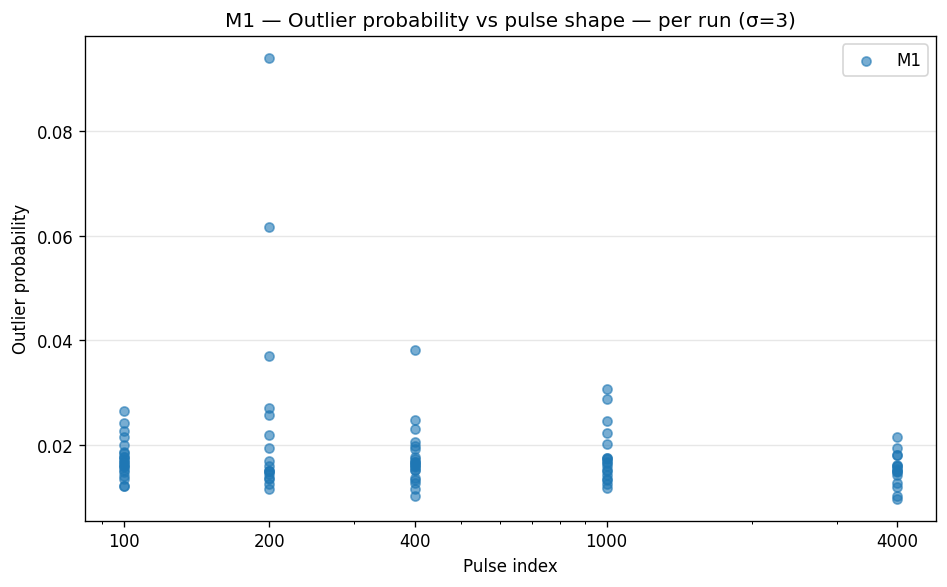

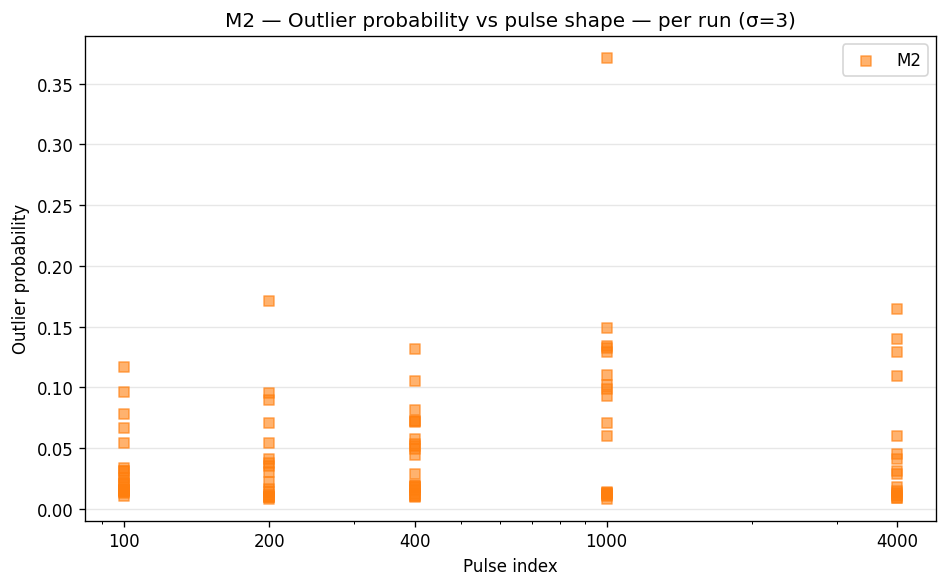

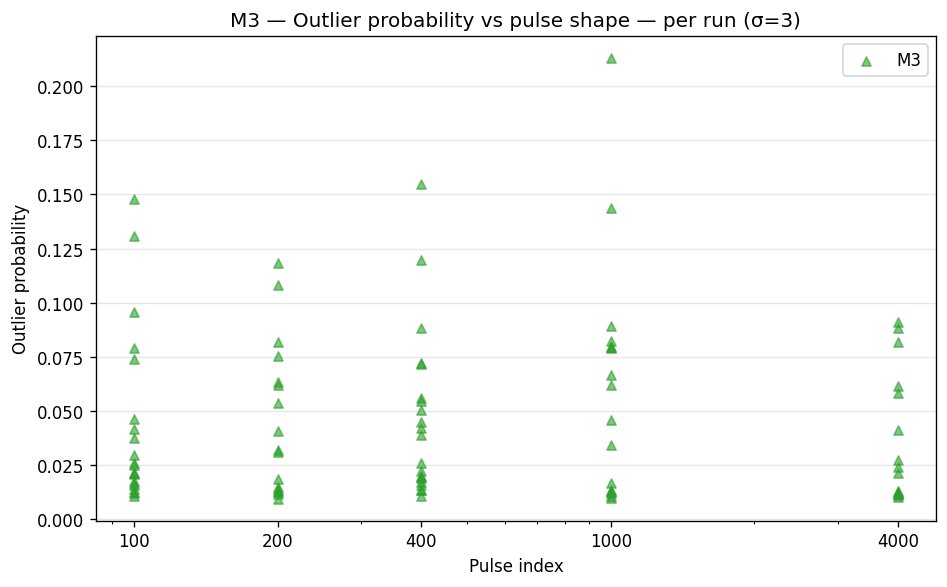

In [18]:
# Group records by pulse_name
from collections import defaultdict
records_by_pulse = defaultdict(list)
for r in summary_records:
    records_by_pulse[r["pulse_name"]].append(r)

sorted_pulse_names = sorted(records_by_pulse.keys(), key=lambda n: PULSE_ORDER[n])
sorted_x = [PULSE_ORDER[n] for n in sorted_pulse_names]

# Build arrays for scatter: each run is a separate point
x_ref, y_ref = [], []
x_set2, y_set2 = [], []
x_set3, y_set3 = [], []

for pname in sorted_pulse_names:
    px = PULSE_ORDER[pname]
    for r in records_by_pulse[pname]:
        x_ref.append(px);   y_ref.append(r["ref_outlier"])
        x_set2.append(px);  y_set2.append(r["set2_outlier"])
        x_set3.append(px);  y_set3.append(r["set3_outlier"])

x_ref = np.array(x_ref, dtype=float)
x_set2 = np.array(x_set2, dtype=float)
x_set3 = np.array(x_set3, dtype=float)

for label, x_arr, y_arr, marker, color in [
    ("M1", x_ref, y_ref, "o", "C0"),
    ("M2", x_set2, y_set2, "s", "C1"),
    ("M3", x_set3, y_set3, "^", "C2"),
]:
    fig, ax = plt.subplots(figsize=(max(8, len(sorted_pulse_names) * 1.5), 5), dpi=120)
    ax.scatter(x_arr, y_arr, marker=marker, s=30, label=label, color=color, alpha=0.6, zorder=3)
    ax.set_xscale("log")
    ax.set_xticks(sorted_x)
    ax.set_xticklabels([str(v) for v in sorted_x])
    ax.set_xlabel("Pulse index")
    ax.set_ylabel("Outlier probability")
    ax.set_title(f"{label} — Outlier probability vs pulse shape — per run (σ={OUTLIER_SIGMA})")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"outlier_vs_pulse_per_run_{label}.png"), dpi=150, bbox_inches="tight")
    plt.show()

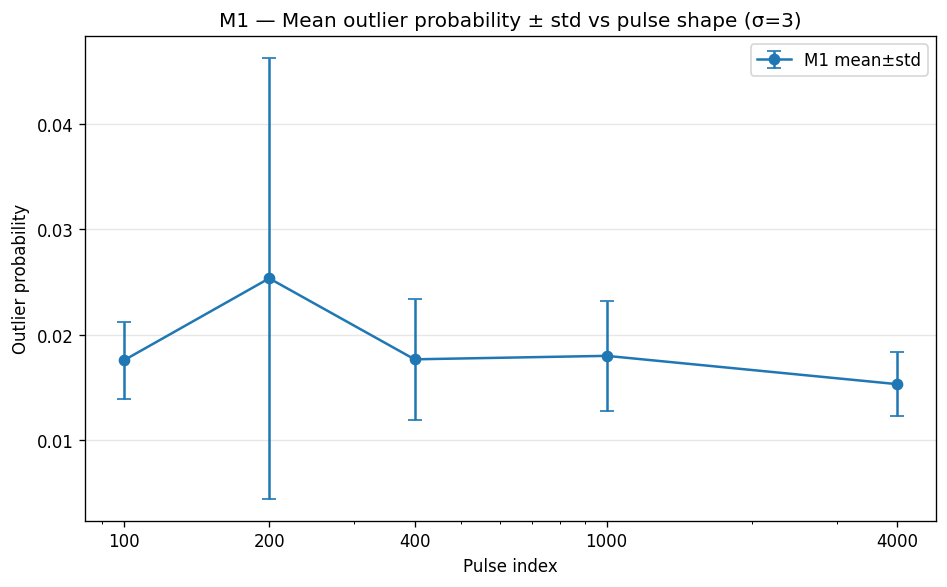

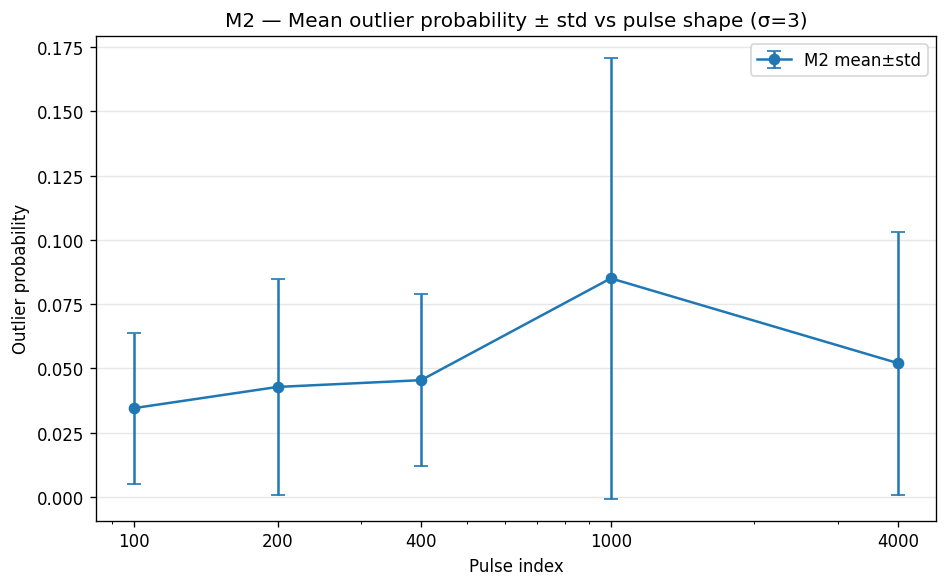

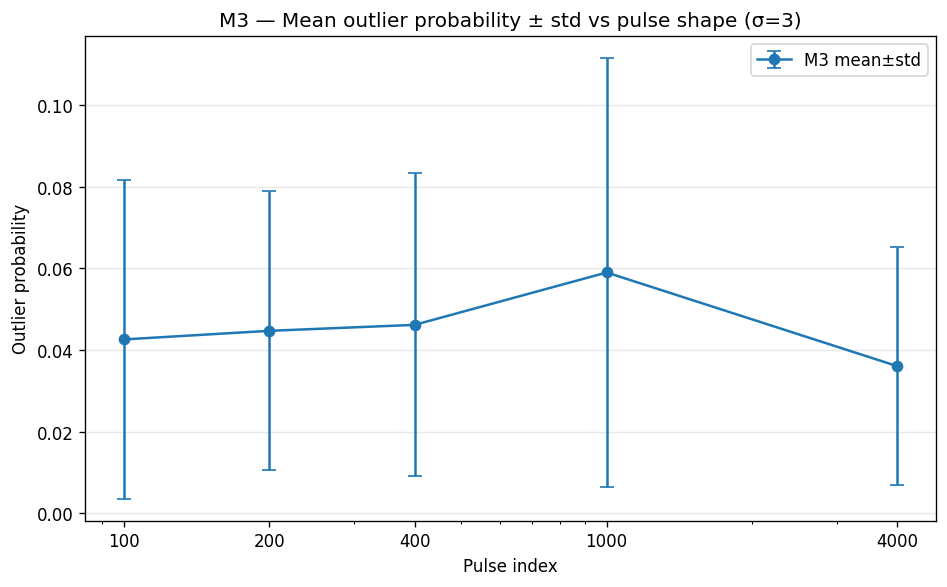

In [19]:
# Mean ± std of outlier probability per pulse shape
for label, key in [("M1", "ref_outlier"), ("M2", "set2_outlier"), ("M3", "set3_outlier")]:
    xs, means, stds = [], [], []
    for pname in sorted_pulse_names:
        px = PULSE_ORDER[pname]
        vals = [r[key] for r in records_by_pulse[pname]]
        xs.append(px)
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    xs = np.array(xs, dtype=float)
    means = np.array(means)
    stds = np.array(stds)

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_pulse_names) * 1.5), 5), dpi=120)
    ax.errorbar(xs, means, yerr=stds, fmt="o-", capsize=4, label=f"{label} mean±std")
    ax.set_xscale("log")
    ax.set_xticks(sorted_x)
    ax.set_xticklabels([str(v) for v in sorted_x])
    ax.set_xlabel("Pulse index")
    ax.set_ylabel("Outlier probability")
    ax.set_title(f"{label} — Mean outlier probability ± std vs pulse shape (σ={OUTLIER_SIGMA})")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"outlier_mean_std_{label}.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 7. Fitted Std vs Pulse Shape (All Runs)

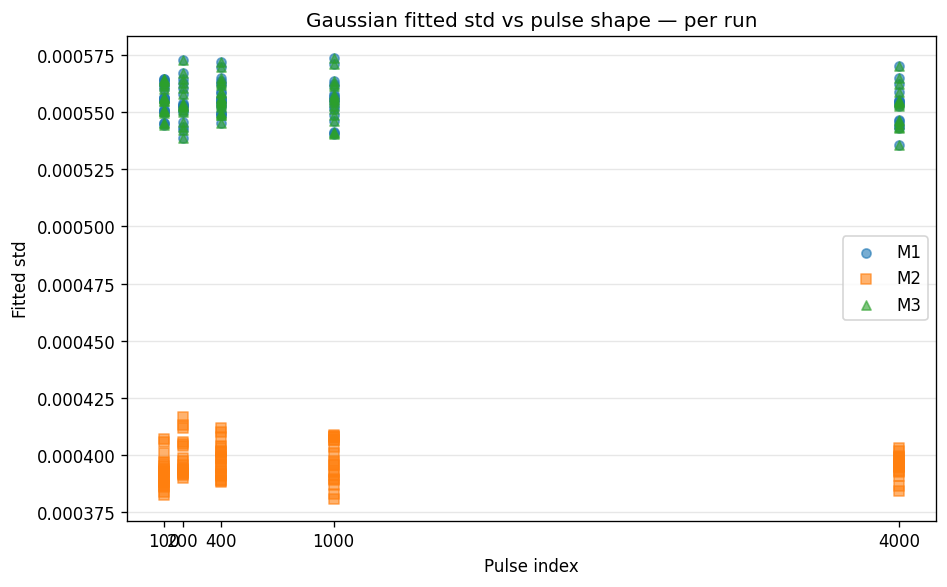

In [20]:
x_std_ref, y_std_ref = [], []
x_std_s2, y_std_s2 = [], []
x_std_s3, y_std_s3 = [], []

for pname in sorted_pulse_names:
    px = PULSE_ORDER[pname]
    for r in records_by_pulse[pname]:
        x_std_ref.append(px); y_std_ref.append(r["ref_std"])
        x_std_s2.append(px);  y_std_s2.append(r["set2_std"])
        x_std_s3.append(px);  y_std_s3.append(r["set3_std"])

fig, ax = plt.subplots(figsize=(max(8, len(sorted_pulse_names) * 1.5), 5), dpi=120)
ax.scatter(x_std_ref, y_std_ref, marker="o", s=30, label="M1", color="C0", alpha=0.6, zorder=3)
ax.scatter(x_std_s2,  y_std_s2,  marker="s", s=30, label="M2", color="C1", alpha=0.6, zorder=3)
ax.scatter(x_std_s3,  y_std_s3,  marker="^", s=30, label="M3", color="C2", alpha=0.6, zorder=3)

ax.set_xticks(sorted_x)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Fitted std")
ax.set_title("Gaussian fitted std vs pulse shape — per run")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "std_vs_pulse_per_run.png"), dpi=150, bbox_inches="tight")
plt.show()